In [1]:
#####소아 청소년 인구수#####

import pandas as pd
import re


# CSV 파일 불러오기 (한글 인코딩 처리)
file_path = "../../data/pediatric/연령별인구.csv"
df = pd.read_csv(file_path, encoding="cp949")

df.head(10)


,행정구역,2023년_계_총인구수,2023년_계_연령구간인구수,2023년_계_0세,2023년_계_1세,2023년_계_2세,2023년_계_3세,2023년_계_4세,2023년_계_5세,2023년_계_6세,...,2023년_계_10세,2023년_계_11세,2023년_계_12세,2023년_계_13세,2023년_계_14세,2023년_계_15세,2023년_계_16세,2023년_계_17세,2023년_계_18세,2023년_계_19세
0,전국 (0000000000),"51,325,329","7,984,352","225,958","253,595","266,619","279,134","309,282","333,705","364,740",...,"441,952","490,229","476,570","473,894","448,324","468,773","495,547","449,025","435,025","472,121"
1,서울특별시 (1100000000),"9,386,034","1,246,773","37,771","41,087","43,013","43,637","47,506","50,291","55,100",...,"66,672","74,287","71,911","72,773","69,371","73,898","78,204","72,331","70,353","83,411"
2,부산광역시 (2600000000),"3,293,362","457,742","12,620","14,371","15,046","15,703","17,620","19,562","21,787",...,"25,885","28,593","27,617","27,042","24,792","26,014","27,317","24,633","24,362","27,084"
3,대구광역시 (2700000000),"2,374,960","364,524","9,288","10,675","11,476","12,056","14,092","15,212","17,059",...,"20,203","22,532","21,803","21,565","20,200","21,384","22,801","20,689","20,740","22,204"
4,인천광역시 (2800000000),"2,997,410","474,408","13,892","15,920","16,423","17,286","19,232","20,398","21,797",...,"26,100","28,713","28,470","27,870","26,350","27,176","29,194","25,915","25,270","27,021"
5,광주광역시 (2900000000),"1,419,237","247,304","6,065","7,459","8,038","8,120","9,234","10,017","11,144",...,"13,742","15,278","14,692","15,002","14,311","14,807","15,962","14,503","14,123","15,105"
6,대전광역시 (3000000000),"1,442,216","234,563","7,161","7,920","7,984","7,917","8,749","9,354","10,571",...,"12,853","13,893","13,872","13,640","13,085","13,918","14,798","13,615","13,187","14,975"
7,울산광역시 (3100000000),"1,103,661","188,548","4,959","5,392","6,090","6,450","7,252","7,898","8,836",...,"10,863","11,936","11,361","11,289","10,723","11,135","11,752","10,343","10,015","10,045"
8,세종특별자치시 (3600000000),"386,525","94,277","2,639","3,184","3,612","3,664","4,124","4,504","4,939",...,"5,499","5,992","5,593","5,610","5,204","5,297","5,100","4,521","4,030","3,890"
9,경기도 (4100000000),"13,630,821","2,310,181","68,030","77,729","80,214","83,766","92,309","99,339","107,355",...,"127,485","141,419","136,489","135,750","128,248","133,672","139,563","126,683","120,669","130,653"


In [2]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   행정구역             18 non-null     object
 1   2023년_계_총인구수     18 non-null     object
 2   2023년_계_연령구간인구수  18 non-null     object
 3   2023년_계_0세       18 non-null     object
 4   2023년_계_1세       18 non-null     object
 5   2023년_계_2세       18 non-null     object
 6   2023년_계_3세       18 non-null     object
 7   2023년_계_4세       18 non-null     object
 8   2023년_계_5세       18 non-null     object
 9   2023년_계_6세       18 non-null     object
 10  2023년_계_7세       18 non-null     object
 11  2023년_계_8세       18 non-null     object
 12  2023년_계_9세       18 non-null     object
 13  2023년_계_10세      18 non-null     object
 14  2023년_계_11세      18 non-null     object
 15  2023년_계_12세      18 non-null     object
 16  2023년_계_13세      18 non-null     object
 17  2023년_계_14세      18 non-null     obje

In [3]:
df.describe(include='all')

,행정구역,2023년_계_총인구수,2023년_계_연령구간인구수,2023년_계_0세,2023년_계_1세,2023년_계_2세,2023년_계_3세,2023년_계_4세,2023년_계_5세,2023년_계_6세,...,2023년_계_10세,2023년_계_11세,2023년_계_12세,2023년_계_13세,2023년_계_14세,2023년_계_15세,2023년_계_16세,2023년_계_17세,2023년_계_18세,2023년_계_19세
count,18,18,18,18,18,18,18,18,18,18,...,18,18,18,18,18,18,18,18,18,18
unique,18,18,18,18,18,18,18,18,18,18,...,18,18,18,18,18,18,18,18,18,18
top,전국 (0000000000),"51,325,329","7,984,352","225,958","253,595","266,619","279,134","309,282","333,705","364,740",...,"441,952","490,229","476,570","473,894","448,324","468,773","495,547","449,025","435,025","472,121"
freq,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [4]:
df.isnull().sum()

행정구역               0
2023년_계_총인구수       0
2023년_계_연령구간인구수    0
2023년_계_0세         0
2023년_계_1세         0
2023년_계_2세         0
2023년_계_3세         0
2023년_계_4세         0
2023년_계_5세         0
2023년_계_6세         0
2023년_계_7세         0
2023년_계_8세         0
2023년_계_9세         0
2023년_계_10세        0
2023년_계_11세        0
2023년_계_12세        0
2023년_계_13세        0
2023년_계_14세        0
2023년_계_15세        0
2023년_계_16세        0
2023년_계_17세        0
2023년_계_18세        0
2023년_계_19세        0
dtype: int64

In [5]:
df.shape

(18, 23)

In [6]:


#행정구역 명칭 깔끔히 변경
df["행정구역"] = (
    df["행정구역"]
    .str.replace(r"\(.*\)", "", regex=True)   # 괄호 전체 제거
    .str.replace(r"\s+", " ", regex=True)     # 여러 공백 → 한 칸
    .str.strip()                               # 앞뒤 공백 제거
)

#불필요한 컬럼 삭제
cols_to_keep = ["행정구역", "2023년_계_연령구간인구수"]
df = df[cols_to_keep]

#전국 행 제거
df = df[df["행정구역"] != "전국"].reset_index(drop=True)

#컬렴명 변환
df = df.rename(columns={
    "2023년_계_연령구간인구수": "소아청소년_인구수"
})

#int로 변환
df["소아청소년_인구수"] = (
    df["소아청소년_인구수"]
    .str.replace(",", "", regex=False)  # 쉼표 제거
    .astype(int)                        # 정수형 변환
)
#전북특별자치도
df["행정구역"] = df["행정구역"].replace("전라북도", "전북특별자치도")

df






,행정구역,소아청소년_인구수
0,서울특별시,1246773
1,부산광역시,457742
2,대구광역시,364524
3,인천광역시,474408
4,광주광역시,247304
5,대전광역시,234563
6,울산광역시,188548
7,세종특별자치시,94277
8,경기도,2310181
9,강원특별자치도,219925


In [7]:
####도시면적####

file_path1 = "../../data/pediatric/도시지역면적.csv"
df1 = pd.read_csv(file_path1, encoding="UTF-8")
df1

,소재지(시군구)별,2022,2023,2024
0,전국,17791754999,17589843385,17639470771
1,서울특별시,605672952,605673772,605748896
2,부산광역시,940844566,940825056,940825056
3,대구광역시,801033747,808195732,808209312
4,인천광역시,527855326,512816173,513676030
5,광주광역시,479890096,479838049,479818783
6,대전광역시,496123890,496123890,496123742
7,울산광역시,764212886,671649337,677663085
8,세종특별자치시,141833041,141833041,142568912
9,경기도,3386898994,3370827754,3397055790


In [8]:
####도시면적####

file_path1 = "../../data/pediatric/도시지역면적.csv"
df1 = pd.read_csv(file_path1, encoding="UTF-8")

#불필요한 컬럼 삭제
df1 = df1[["소재지(시군구)별", "2023"]]

#컬럼명 변경
df1 = df1.rename(columns={
    "소재지(시군구)별": "행정구역",
    "2023": "도시면적"
})

#전국 행 삭제
df1 = df1[df1["행정구역"] != "전국"].reset_index(drop=True)

#면적 단위 통일
df1["도시면적"] = (df1["도시면적"] / 1_000_000).astype(int)
df1


,행정구역,도시면적
0,서울특별시,605
1,부산광역시,940
2,대구광역시,808
3,인천광역시,512
4,광주광역시,479
5,대전광역시,496
6,울산광역시,671
7,세종특별자치시,141
8,경기도,3370
9,강원특별자치도,1004


In [9]:
####지역전체면적####

file_path2= "../../data/pediatric/지역전체면적.csv"
df2 = pd.read_csv(file_path2, encoding="UTF-8")
df2.head(10)


,남북한별,2006,2006.1,2007,2007.1,2008,2008.1,2009,2009.1,2010,...,2019,2019.1,2020,2020.1,2021,2021.1,2022,2022.1,2023,2023.1
0,남북한별,면적 (㎢),구성비 (%),면적 (㎢),구성비 (%),면적 (㎢),구성비 (%),면적 (㎢),구성비 (%),면적 (㎢),...,면적 (㎢),구성비 (%),면적 (㎢),구성비 (%),면적 (㎢),구성비 (%),면적 (㎢),구성비 (%),면적 (㎢),구성비 (%)
1,북한,123138,100.0,123138,100.0,123138,100.0,123138,100.0,123138,...,123214,100.0,123214,100.0,123214,100.0,123214,100.0,123214,100.0
2,평양직할시,2629,2.1,2629,2.1,2629,2.1,2629,2.1,1587,...,1849,1.5,1849,1.5,1849,1.5,1849,1.5,1849,1.5
3,나선특별시,945,0.8,945,0.8,945,0.8,945,0.8,945,...,904,0.7,904,0.7,904,0.7,904,0.7,904,0.7
4,남포특별시,-,-,-,-,-,-,829,0.7,1142,...,1295,1.1,1295,1.1,1295,1.1,1295,1.1,1295,1.1
5,개성특별시,-,-,-,-,-,-,-,-,-,...,755,0.6,755,0.6,755,0.6,755,0.6,1298,1.1
6,평안남도,12720,10.3,12720,10.3,12720,10.3,11891,9.7,11578,...,11497,9.3,11497,9.3,11497,9.3,11497,9.3,11497,9.3
7,평안북도,12680,10.3,12680,10.3,12680,10.3,12680,10.3,12680,...,12654,10.3,12654,10.3,12654,10.3,12654,10.3,12171,9.9
8,함경남도,18535,15.1,18535,15.1,18535,15.1,18535,15.1,18535,...,18601,15.1,18601,15.1,18601,15.1,18601,15.1,18601,15.1
9,함경북도,15980,13.0,15980,13.0,15980,13.0,15980,13.0,15980,...,15830,12.8,15830,12.8,15830,12.8,15830,12.8,15830,12.8


In [10]:
####지역전체면적####

file_path2= "../../data/pediatric/지역전체면적.csv"
df2 = pd.read_csv(file_path2, encoding="UTF-8")

#공백제거
df2.columns = df2.columns.str.strip()

#17개 시도행만 추출
sido_list = [
    "서울특별시", "부산광역시", "대구광역시", "인천광역시", "광주광역시",
    "대전광역시", "울산광역시", "세종특별자치시",
    "경기도", "강원특별자치도", "충청북도", "충청남도",
    "전라북도", "전라남도",
    "경상북도", "경상남도", "제주특별자치도"
]
df2 = df2[df2["남북한별"].isin(sido_list)].reset_index(drop=True)

#필요컬럼만 남김
df2 = df2[["남북한별", "2023"]].copy()

#컬럼이름 변경
df2 = df2.rename(columns={
    "남북한별": "행정구역",
    "2023": "지역전체면적"
})
#int변환
df2["지역전체면적"] = df2["지역전체면적"].astype(int)
#전북특별자치도
df2["행정구역"] = df2["행정구역"].replace("전라북도", "전북특별자치도")


df2


,행정구역,지역전체면적
0,서울특별시,605
1,부산광역시,771
2,대구광역시,1499
3,인천광역시,1067
4,광주광역시,501
5,대전광역시,540
6,울산광역시,1063
7,세종특별자치시,465
8,경기도,10200
9,강원특별자치도,16831


In [11]:
###병원수###
df3 = pd.read_excel('../../data/pediatric/소아청소년과_병원수.xlsx')

#빈 행 제거
df3 = df3.dropna(how="all")

#헤더 바꾸기
df3.columns = df3.iloc[0]
df3 = df3.drop(df3.index[0])

#필요컬럼만 선택
df3 = df3[["시도", "시군구", "소아청소년과"]].copy()

#시도별로만 남기기
df3 = df3[df3["시군구"] == "계"].reset_index(drop=True)
df3 = df3[["시도", "소아청소년과"]]
df3 = df3.rename(columns={
    "시도": "행정구역",
    "소아청소년과": "소아청소년과_병원수"
})

#병원수 int로 변환
df3["소아청소년과_병원수"] = df3["소아청소년과_병원수"].astype(int)

#전북특별자치도
df3["행정구역"] = df3["행정구역"].replace("전라북도", "전북특별자치도")

df3


/opt/homebrew/Caskroom/miniforge/base/envs/2025SDA/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


1,행정구역,소아청소년과_병원수
0,서울특별시,451
1,부산광역시,137
2,대구광역시,116
3,인천광역시,143
4,광주광역시,42
5,대전광역시,56
6,울산광역시,34
7,세종특별자치시,26
8,경기도,680
9,충청북도,56


In [12]:
#세개의 데이터프레임 합침
df_final = (
    df.merge(df2, on="행정구역", how="inner")
      .merge(df1, on="행정구역", how="inner")
      .merge(df3, on="행정구역", how="inner")
)

#소숫점 버림
df_final["도시면적"] = df_final["도시면적"].astype(int)

df_final


,행정구역,소아청소년_인구수,지역전체면적,도시면적,소아청소년과_병원수
0,서울특별시,1246773,605,605,451
1,부산광역시,457742,771,940,137
2,대구광역시,364524,1499,808,116
3,인천광역시,474408,1067,512,143
4,광주광역시,247304,501,479,42
5,대전광역시,234563,540,496,56
6,울산광역시,188548,1063,671,34
7,세종특별자치시,94277,465,141,26
8,경기도,2310181,10200,3370,680
9,강원특별자치도,219925,16831,1004,57


In [13]:
df_final.describe()

,소아청소년_인구수,지역전체면적,도시면적,소아청소년과_병원수
count,1.700000e+01,17.000000,17.000000,17.000000
mean,4.696678e+05,5908.764706,1034.058824,126.588235
std,5.403141e+05,6097.819575,789.544843,173.780414
min,9.427700e+04,465.000000,141.000000,25.000000
25%,2.345630e+05,771.000000,512.000000,42.000000
50%,2.667860e+05,1850.000000,808.000000,65.000000
75%,4.577420e+05,10200.000000,1004.000000,116.000000
max,2.310181e+06,18424.000000,3370.000000,680.000000


In [14]:
print(df1.head())

    행정구역  도시면적
0  서울특별시   605
1  부산광역시   940
2  대구광역시   808
3  인천광역시   512
4  광주광역시   479


In [15]:
print(df2.head())   # 전체면적이 들어있는 원본 df3

    행정구역  지역전체면적
0  서울특별시     605
1  부산광역시     771
2  대구광역시    1499
3  인천광역시    1067
4  광주광역시     501


/var/folders/80/x9ztm2rs5c33hn_3qt3qb6ww0000gn/T/ipykernel_80230/2202470340.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


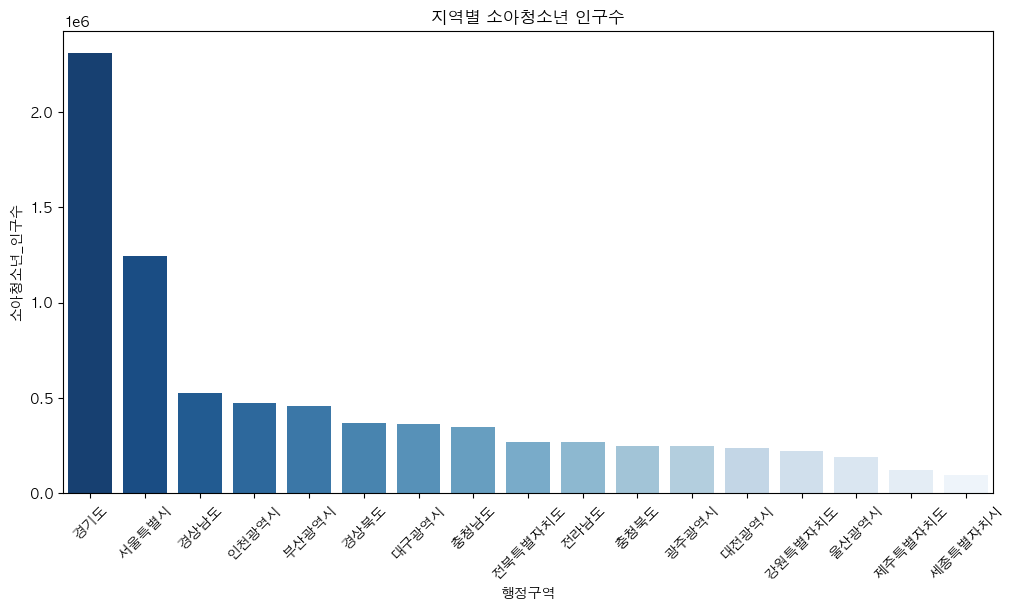

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "AppleGothic"   # macOS 한글 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False    # 마이너스 깨짐 방지

#소아인구수
plt.figure(figsize=(12,6))
sns.barplot(
    x="행정구역",
    y="소아청소년_인구수",
    data=df_final.sort_values("소아청소년_인구수", ascending=False),
    palette="Blues_r"
)
plt.xticks(rotation=45)
plt.title("지역별 소아청소년 인구수")
plt.show()



/var/folders/80/x9ztm2rs5c33hn_3qt3qb6ww0000gn/T/ipykernel_80230/2668633343.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


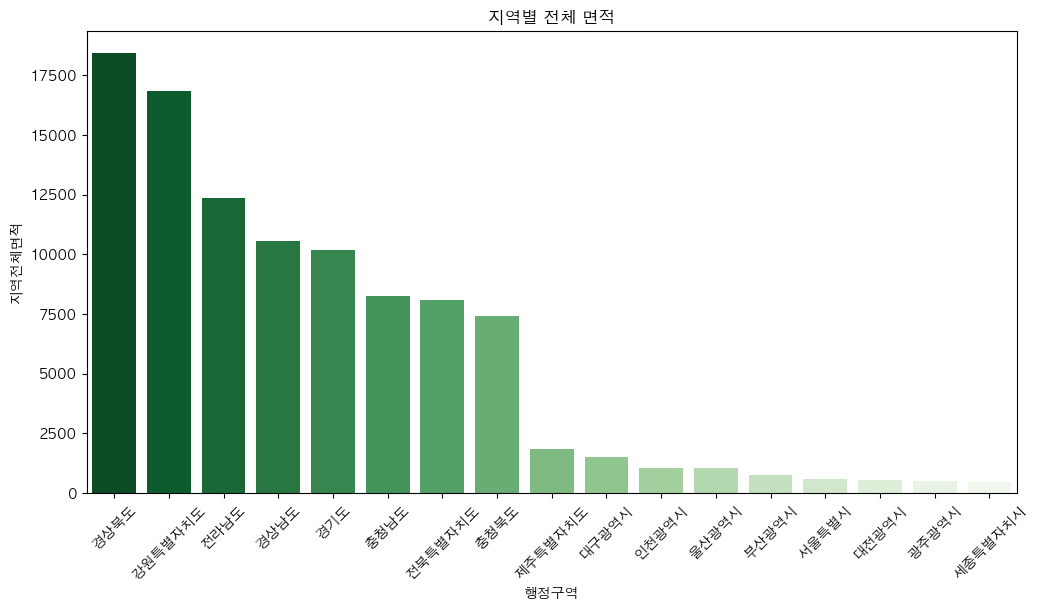

In [17]:
plt.figure(figsize=(12,6))
sns.barplot(
    x="행정구역",
    y="지역전체면적",
    data=df_final.sort_values("지역전체면적", ascending=False),
    palette="Greens_r"
)
plt.xticks(rotation=45)
plt.title("지역별 전체 면적")
plt.show()


/var/folders/80/x9ztm2rs5c33hn_3qt3qb6ww0000gn/T/ipykernel_80230/3834694541.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


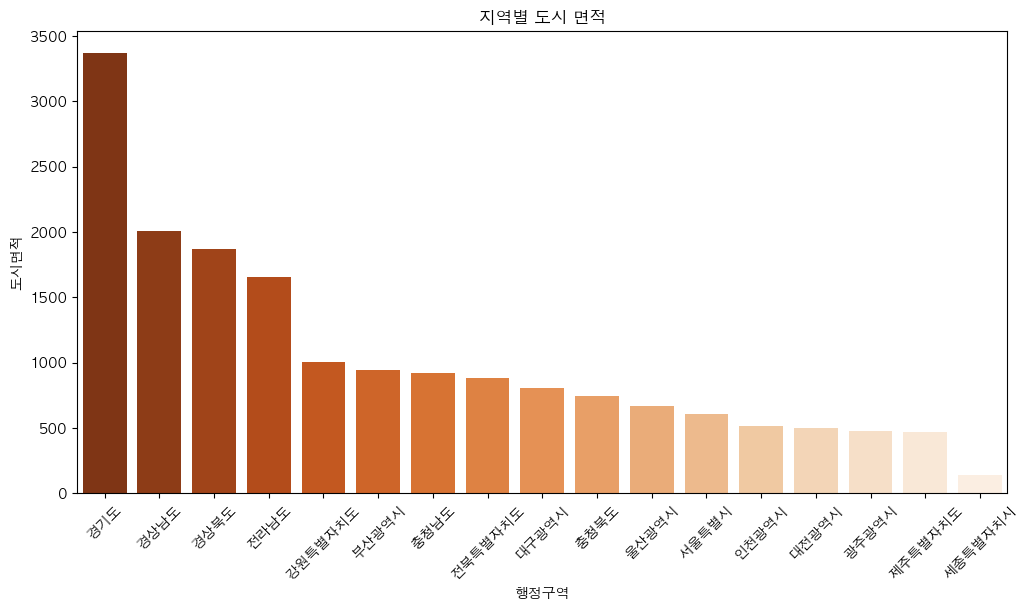

In [18]:
plt.figure(figsize=(12,6))
sns.barplot(
    x="행정구역",
    y="도시면적",
    data=df_final.sort_values("도시면적", ascending=False),
    palette="Oranges_r"
)
plt.xticks(rotation=45)
plt.title("지역별 도시 면적")
plt.show()

/var/folders/80/x9ztm2rs5c33hn_3qt3qb6ww0000gn/T/ipykernel_80230/4282525201.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


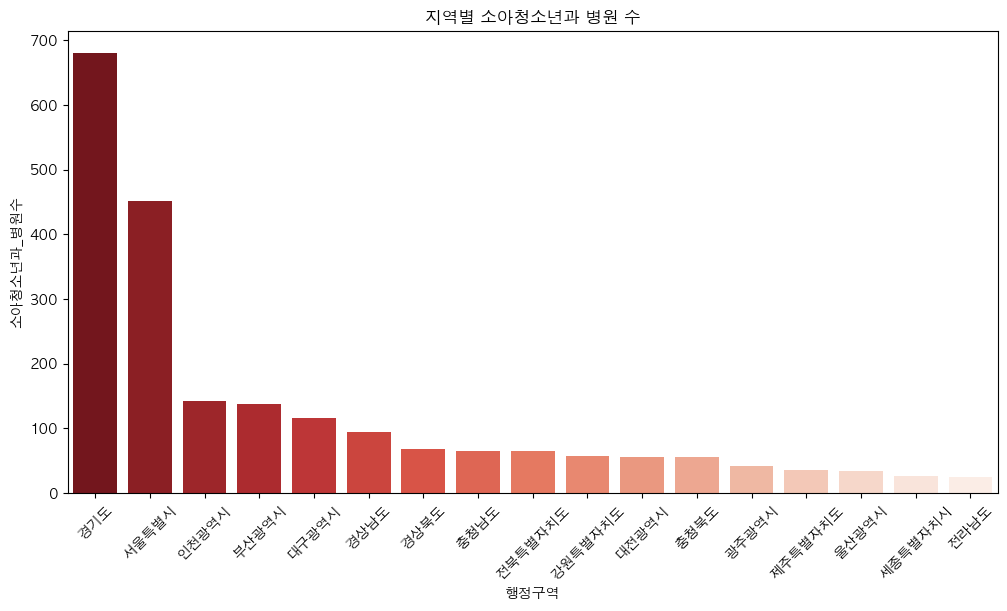

In [19]:
plt.figure(figsize=(12,6))
sns.barplot(
    x="행정구역",
    y="소아청소년과_병원수",
    data=df_final.sort_values("소아청소년과_병원수", ascending=False),
    palette="Reds_r"
)
plt.xticks(rotation=45)
plt.title("지역별 소아청소년과 병원 수")
plt.show()

/var/folders/80/x9ztm2rs5c33hn_3qt3qb6ww0000gn/T/ipykernel_80230/3298891144.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


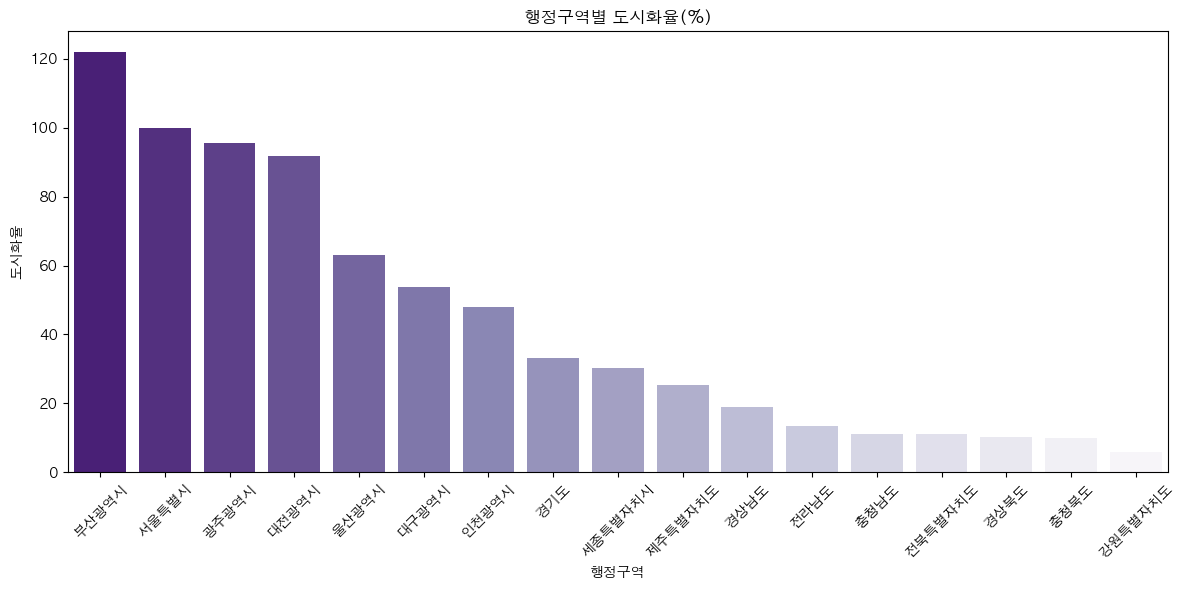

In [20]:
df_final["도시화율"] = df_final["도시면적"] / df_final["지역전체면적"] * 100

plt.figure(figsize=(12,6))
sns.barplot(
    data=df_final.sort_values("도시화율", ascending=False),
    x="행정구역", y="도시화율", palette="Purples_r"
)
plt.title("행정구역별 도시화율(%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


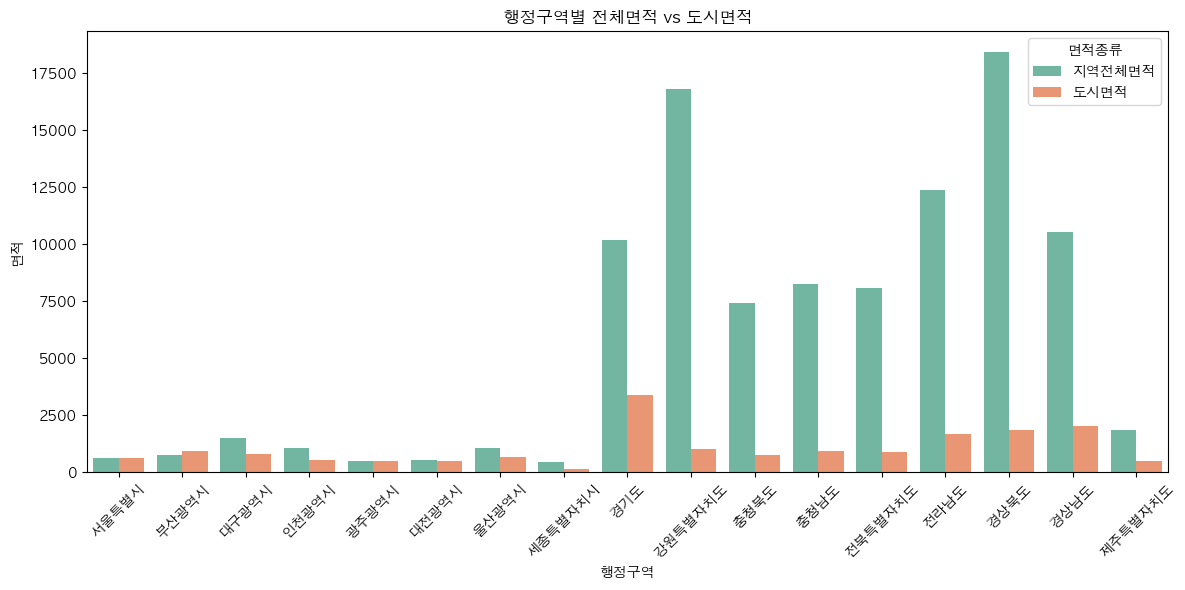

In [21]:
df_melt = df_final.melt(id_vars="행정구역",
                        value_vars=["지역전체면적", "도시면적"],
                        var_name="면적종류",
                        value_name="면적")

plt.figure(figsize=(12,6))
sns.barplot(
    data=df_melt,
    x="행정구역", y="면적", hue="면적종류", palette="Set2"
)
plt.title("행정구역별 전체면적 vs 도시면적")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


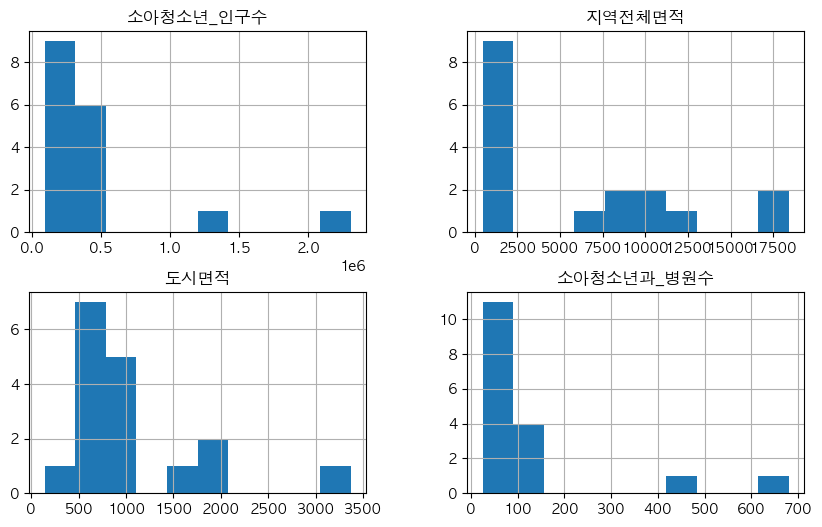

In [22]:
import matplotlib.pyplot as plt

df_final[['소아청소년_인구수','지역전체면적','도시면적','소아청소년과_병원수']].hist(figsize=(10,6))
plt.show()

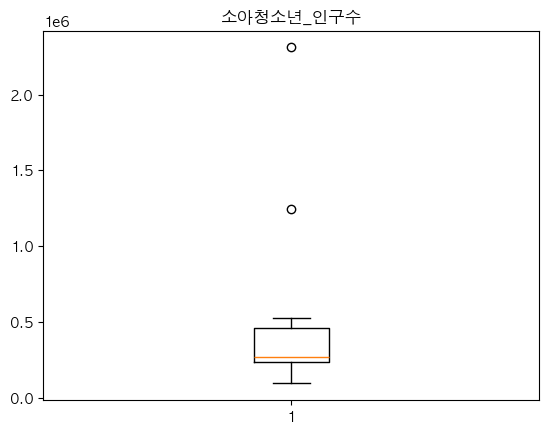

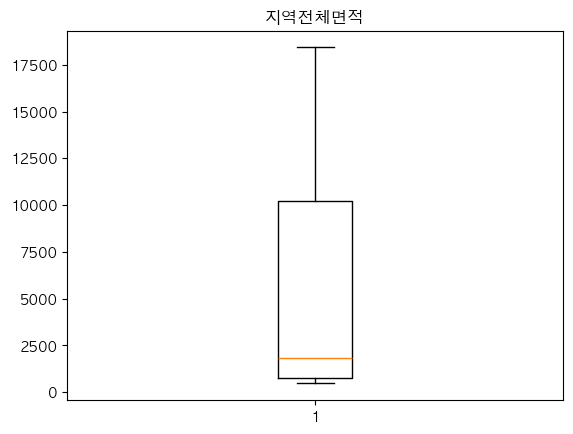

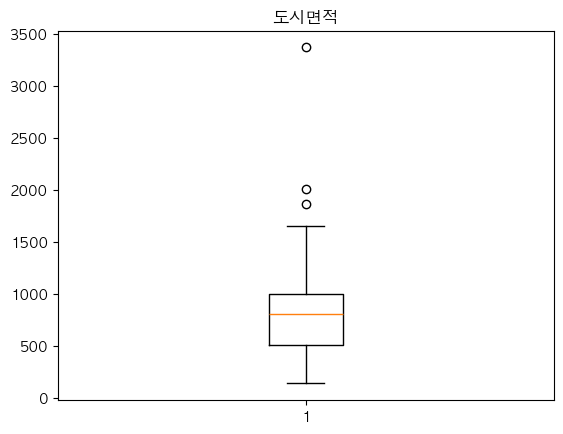

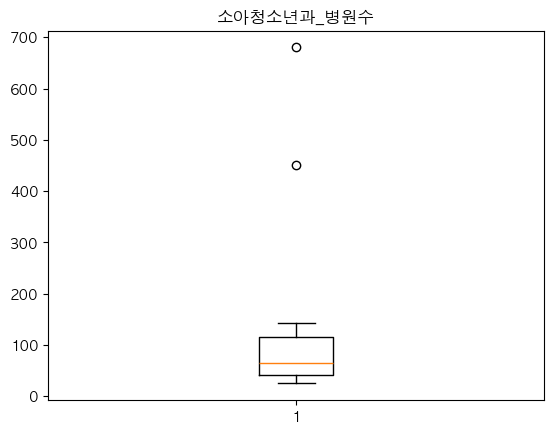

In [23]:
for col in ['소아청소년_인구수','지역전체면적','도시면적','소아청소년과_병원수']:
    plt.boxplot(df_final[col])
    plt.title(col)
    plt.show()

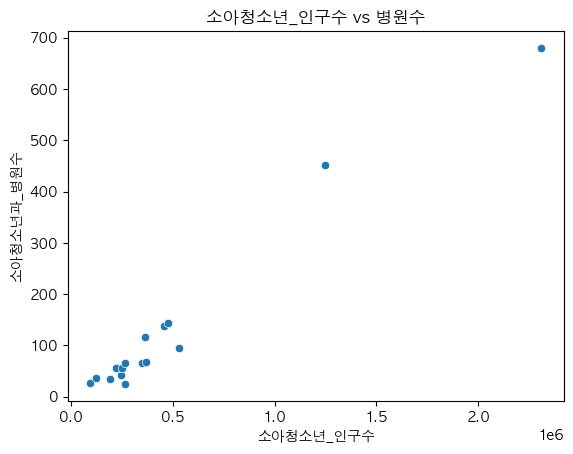

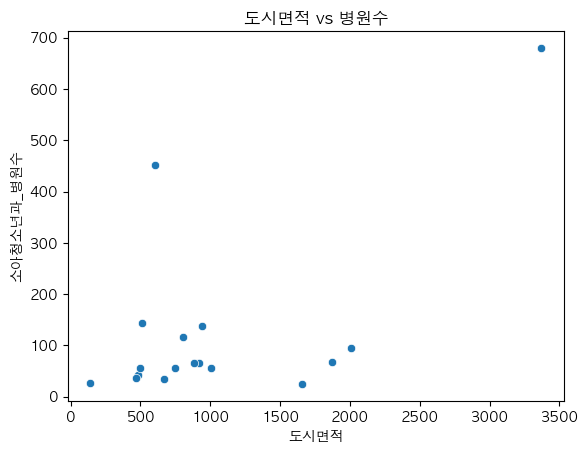

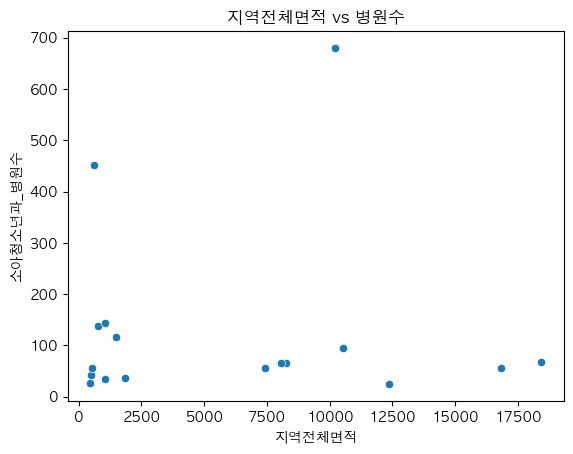

In [24]:
import seaborn as sns

for col in ['소아청소년_인구수','도시면적','지역전체면적']:
    sns.scatterplot(x=col, y='소아청소년과_병원수', data=df_final)
    plt.title(f"{col} vs 병원수")
    plt.show()

In [25]:
from scipy.stats import shapiro

print(df_final.dtypes)
#정규성 검정
print(shapiro(df_final['소아청소년_인구수']))
print(shapiro(df_final['소아청소년과_병원수']))

행정구역           object
소아청소년_인구수       int64
지역전체면적          int64
도시면적            int64
소아청소년과_병원수      int64
도시화율          float64
dtype: object
ShapiroResult(statistic=np.float64(0.5934517825296852), pvalue=np.float64(9.002650048661254e-06))
ShapiroResult(statistic=np.float64(0.5794468750852625), pvalue=np.float64(6.6282013811299875e-06))


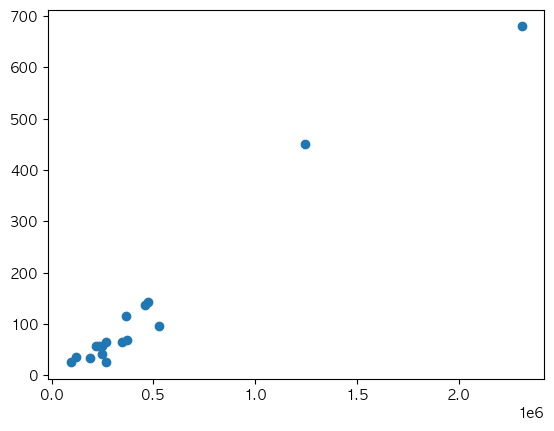

In [26]:
import matplotlib.pyplot as plt
plt.scatter(df_final['소아청소년_인구수'], df_final['소아청소년과_병원수'])

{'whiskers': [<matplotlib.lines.Line2D at 0x12f84bf90>,
 'caps': [<matplotlib.lines.Line2D at 0x12f859750>,
 'boxes': [<matplotlib.lines.Line2D at 0x12f83e410>],
 'medians': [<matplotlib.lines.Line2D at 0x12f85add0>],
 'fliers': [<matplotlib.lines.Line2D at 0x12f85b950>],
 'means': []}

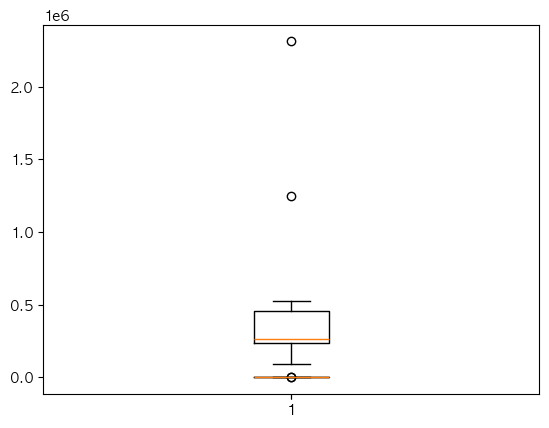

In [27]:
plt.boxplot(df_final['소아청소년_인구수'])
plt.boxplot(df_final['소아청소년과_병원수'])

In [28]:
#가설검정
from scipy.stats import spearmanr
corr, p = spearmanr(df_final['소아청소년_인구수'],
                    df_final['소아청소년과_병원수'])
print(corr, p)


0.8895712217784308 1.7652306605174078e-06


In [29]:
from scipy.stats import shapiro

print(shapiro(df_final['지역전체면적']))
print(shapiro(df_final['소아청소년과_병원수']))

ShapiroResult(statistic=np.float64(0.8284067828373416), pvalue=np.float64(0.005111549935271839))
ShapiroResult(statistic=np.float64(0.5794468750852625), pvalue=np.float64(6.6282013811299875e-06))


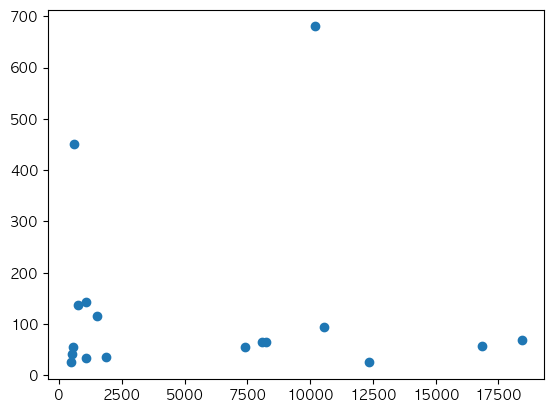

In [30]:
import matplotlib.pyplot as plt
plt.scatter(df_final['지역전체면적'], df_final['소아청소년과_병원수'])

{'whiskers': [<matplotlib.lines.Line2D at 0x12f937090>,
 'caps': [<matplotlib.lines.Line2D at 0x12f944850>,
 'boxes': [<matplotlib.lines.Line2D at 0x12f8f63d0>],
 'medians': [<matplotlib.lines.Line2D at 0x12f945ed0>],
 'fliers': [<matplotlib.lines.Line2D at 0x12f9469d0>],
 'means': []}

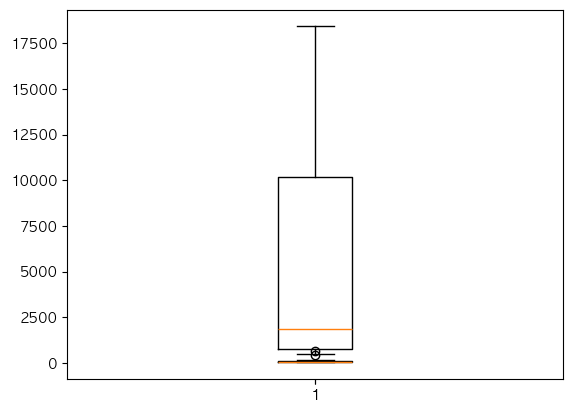

In [31]:
plt.boxplot(df_final['지역전체면적'])
plt.boxplot(df_final['소아청소년과_병원수'])

In [32]:
#가설검정
from scipy.stats import spearmanr
corr1, p1 = spearmanr(df_final['지역전체면적'],
                    df_final['소아청소년과_병원수'])
print(corr1, p1)

0.13251543717526973 0.6121524029067718


In [33]:
print(shapiro(df_final['도시면적']))
print(shapiro(df_final['소아청소년과_병원수']))

ShapiroResult(statistic=np.float64(0.8011612941467038), pvalue=np.float64(0.002104472494906339))
ShapiroResult(statistic=np.float64(0.5794468750852625), pvalue=np.float64(6.6282013811299875e-06))


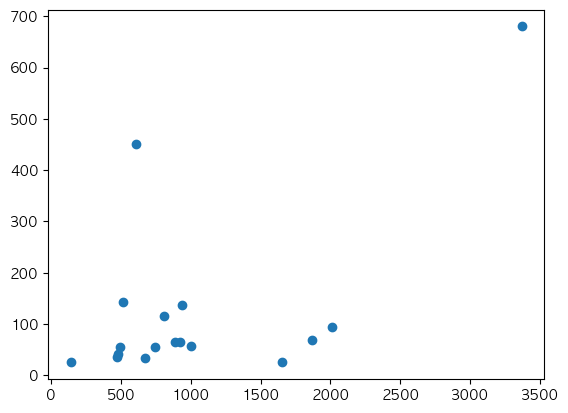

In [34]:
plt.scatter(df_final['도시면적'], df_final['소아청소년과_병원수'])

{'whiskers': [<matplotlib.lines.Line2D at 0x12fa34bd0>,
 'caps': [<matplotlib.lines.Line2D at 0x12fa36210>,
 'boxes': [<matplotlib.lines.Line2D at 0x12fa1ab90>],
 'medians': [<matplotlib.lines.Line2D at 0x12fa37890>],
 'fliers': [<matplotlib.lines.Line2D at 0x12fa3c450>],
 'means': []}

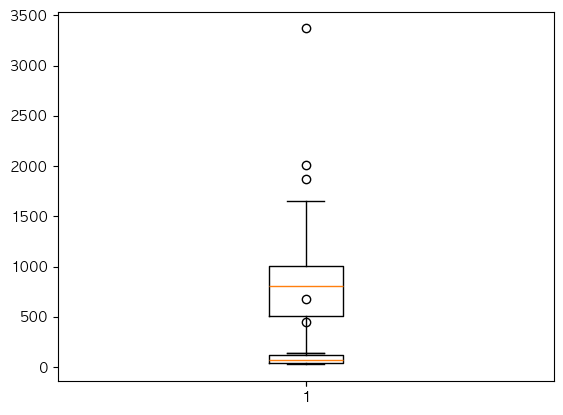

In [35]:
plt.boxplot(df_final['도시면적'])
plt.boxplot(df_final['소아청소년과_병원수'])

In [36]:
#가설검정
from scipy.stats import spearmanr
corr2, p2 = spearmanr(df_final['도시면적'],
                    df_final['소아청소년과_병원수'])
print(corr2, p2)

0.4085892646237483 0.10345445121282182


In [42]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1) 사용할 X 변수 선택
X = df_final[["도시면적", "지역전체면적", "소아청소년_인구수"]].copy()

# 2) 상수항 추가
X = sm.add_constant(X)

# 3) VIF 계산
vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_df)

    variable       VIF
0      const  2.859037
1       도시면적  5.493421
2     지역전체면적  2.766838
3  소아청소년_인구수  3.329307


In [37]:
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.ols("소아청소년과_병원수 ~ 소아청소년_인구수", data=df_final).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             소아청소년과_병원수   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.969
Method:                 Least Squares   F-statistic:                     499.2
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           6.30e-13
Time:                        14:14:50   Log-Likelihood:                -81.245
No. Observations:                  17   AIC:                             166.5
Df Residuals:                      15   BIC:                             168.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -22.2507      9.983     -2.229      0.0

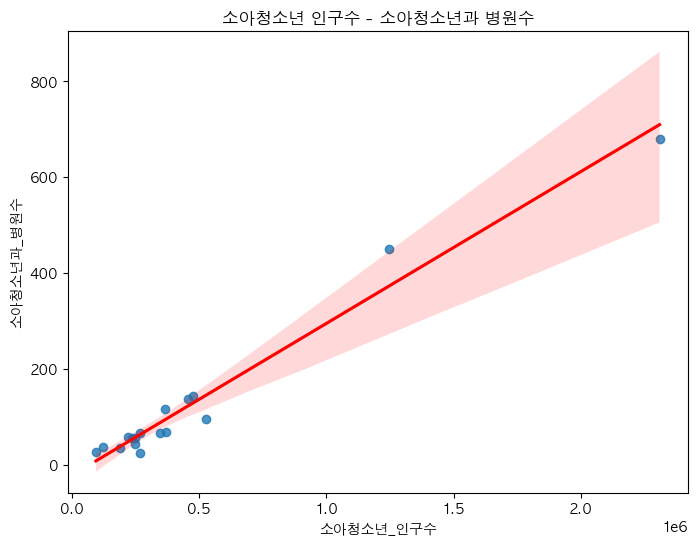

In [38]:
#회귀결과 그래프 

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.regplot(
    x="소아청소년_인구수", 
    y="소아청소년과_병원수", 
    data=df_final,
    line_kws={"color":"red"}
)
plt.title("소아청소년 인구수 - 소아청소년과 병원수")
plt.show()


In [39]:
#단순회귀 모델로 예측값(예상 병원수) 계산
df_final["예측값"] = model.fittedvalues
df_final["잔차"] = model.resid
df_final

,행정구역,소아청소년_인구수,지역전체면적,도시면적,소아청소년과_병원수,도시화율,예측값,잔차
0,서울특별시,1246773,605,605,451,100.000000,372.854848,78.145152
1,부산광역시,457742,771,940,137,121.919585,122.808930,14.191070
2,대구광역시,364524,1499,808,116,53.902602,93.267911,22.732089
3,인천광역시,474408,1067,512,143,47.985005,128.090428,14.909572
4,광주광역시,247304,501,479,42,95.608782,56.120596,-14.120596
5,대전광역시,234563,540,496,56,91.851852,52.082941,3.917059
6,울산광역시,188548,1063,671,34,63.123236,37.500671,-3.500671
7,세종특별자치시,94277,465,141,26,30.322581,7.625953,18.374047
8,경기도,2310181,10200,3370,680,33.039216,709.851531,-29.851531
9,강원특별자치도,219925,16831,1004,57,5.965183,47.444122,9.555878


/var/folders/80/x9ztm2rs5c33hn_3qt3qb6ww0000gn/T/ipykernel_80230/2963588831.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


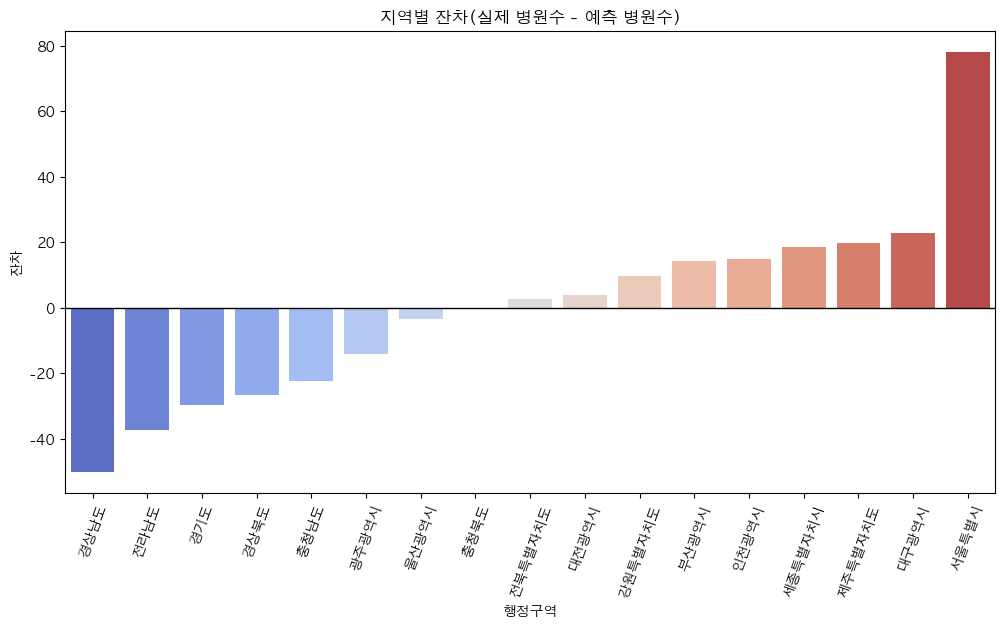

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(
    x="행정구역",
    y="잔차",
    data=df_final.sort_values("잔차"),
    palette="coolwarm"
)
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=70)
plt.title("지역별 잔차(실제 병원수 - 예측 병원수)")
plt.ylabel("잔차")
plt.show()

In [44]:
import statsmodels.formula.api as smf

model = smf.ols("소아청소년과_병원수 ~ 도시면적 + 지역전체면적 + 소아청소년_인구수", data=df_final).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             소아청소년과_병원수   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     734.3
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           9.46e-15
Time:                        15:23:46   Log-Likelihood:                -67.612
No. Observations:                  17   AIC:                             143.2
Df Residuals:                      13   BIC:                             146.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.1565      6.056      0.356      0.7